<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install vegas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.3 MB/s eta 0:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import vegas

In [3]:
def transformed_function(z):
    return np.sin(np.sqrt(z)) * (1 / (2 * np.sqrt(z)))

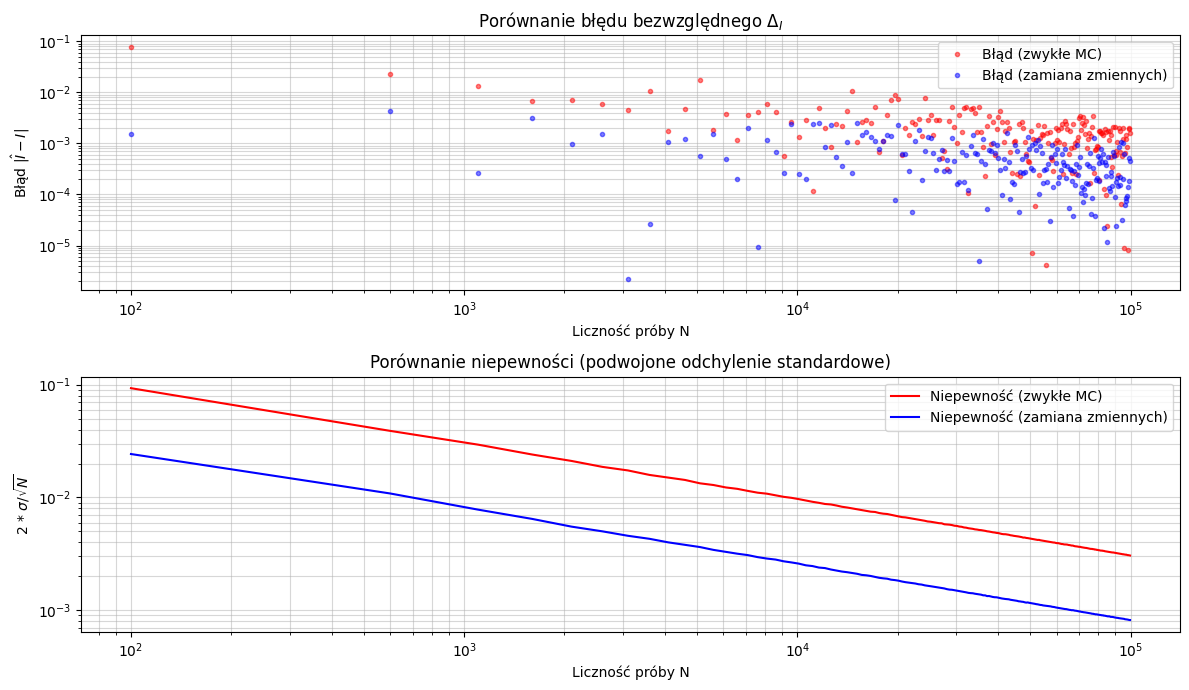

In [4]:
# 1. Obliczenie analityczne
I_analytical = 1.0

# Zakresy całkowania
x_min, x_max = 0, np.pi / 2
z_min, z_max = 0, (np.pi / 2)**2

N_values = []
n = 100
while n <= 100000:
    N_values.append(n)
    n += 500

results = {
    'direct': {'error': [], 'uncertainty': []},
    'transformed': {'error': [], 'uncertainty': []}
}

for N in N_values:
    # Metoda bezpośrednia
    x_samples = np.random.uniform(x_min, x_max, N)
    f_x = np.sin(x_samples)
    I_hat_direct = (x_max - x_min) * np.mean(f_x)
    std_direct = (x_max - x_min) * np.std(f_x) / np.sqrt(N)

    results['direct']['error'].append(abs(I_hat_direct - I_analytical))
    results['direct']['uncertainty'].append(2 * std_direct)

    # Metoda z zamianą zmiennych
    z_samples = np.random.uniform(z_min, z_max, N)
    f_z = transformed_function(z_samples)
    I_hat_trans = (z_max - z_min) * np.mean(f_z)
    std_trans = (z_max - z_min) * np.std(f_z) / np.sqrt(N)

    results['transformed']['error'].append(abs(I_hat_trans - I_analytical))
    results['transformed']['uncertainty'].append(2 * std_trans)

plt.figure(figsize=(12, 7))

# Błąd bezwzględny - dodano r'...'
plt.subplot(2, 1, 1)
plt.loglog(N_values, results['direct']['error'], 'r.', label='Błąd (zwykłe MC)', alpha=0.5)
plt.loglog(N_values, results['transformed']['error'], 'b.', label='Błąd (zamiana zmiennych)', alpha=0.5)
plt.title(r'Porównanie błędu bezwzględnego $\Delta_I$')
plt.xlabel('Liczność próby N')
plt.ylabel(r'Błąd $| \hat{I} - I |$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# Niepewność - dodano r'...'
plt.subplot(2, 1, 2)
plt.loglog(N_values, results['direct']['uncertainty'], 'r-', label='Niepewność (zwykłe MC)')
plt.loglog(N_values, results['transformed']['uncertainty'], 'b-', label='Niepewność (zamiana zmiennych)')
plt.title('Porównanie niepewności (podwojone odchylenie standardowe)')
plt.xlabel('Liczność próby N')
plt.ylabel(r'2 * $\sigma / \sqrt{N}$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

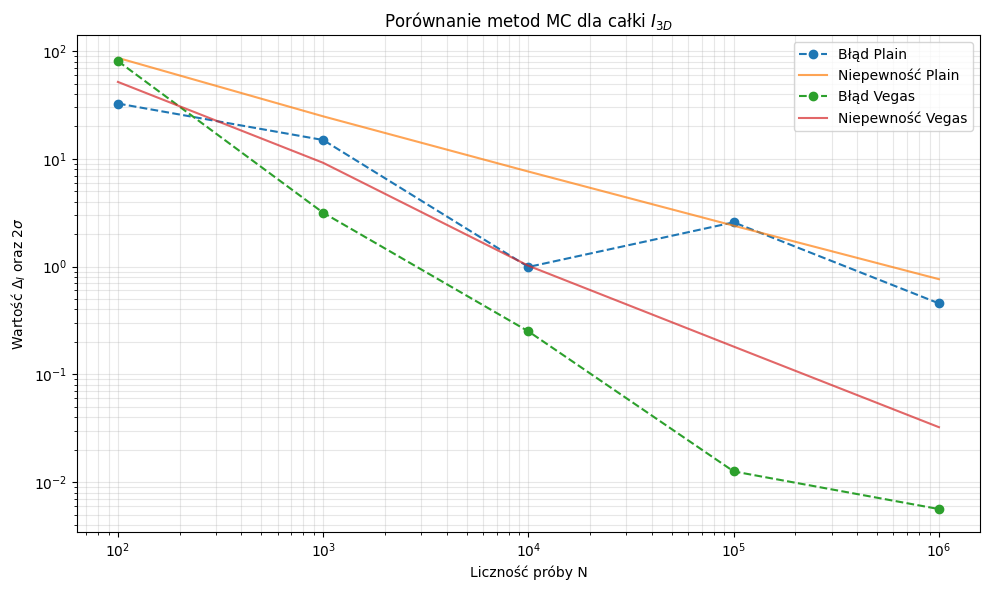

In [7]:
# 1. Wartości analityczne
# Integral of (1 + cos(x)) from -pi to pi = [x + sin(x)] from -pi to pi = 2*pi
I_1D_exact = 2 * np.pi
# Dla 3D: (2*pi)^3
I_3D_exact = (2 * np.pi)**3

# 2. Definicje funkcji podcałkowych
def f1d(x):
    return 1 + np.cos(x[0])

def f3d(x):
    return (1 + np.cos(x[0])) * (1 + np.cos(x[1])) * (1 + np.cos(x[2]))


N_values = [100, 1000, 10000, 100000, 1000000]

# Słownik na wyniki dla funkcji 3D (przykład dla 3D)
methods = {
    'Plain': {'error': [], 'uncertainty': []},
    'Vegas': {'error': [], 'uncertainty': []},
}

# Zakresy całkowania [-pi, pi] dla 3 wymiarów
dim = 3
region = [[-np.pi, np.pi]] * dim

for N in N_values:
    # --- Metoda Plain (proste MC) ---
    samples = np.random.uniform(-np.pi, np.pi, (N, dim))
    f_vals = (1 + np.cos(samples[:, 0])) * (1 + np.cos(samples[:, 1])) * (1 + np.cos(samples[:, 2]))
    vol = (2 * np.pi)**dim
    I_hat_plain = vol * np.mean(f_vals)
    std_plain = vol * np.std(f_vals) / np.sqrt(N)

    methods['Plain']['error'].append(abs(I_hat_plain - I_3D_exact))
    methods['Plain']['uncertainty'].append(2 * std_plain)

    # --- Metoda Vegas ---
    integ = vegas.Integrator(region)
    # Trenujemy mapę Vegas, a potem wykonujemy właściwe całkowanie
    integ(f3d, nitn=5, neval=N // 5) # Rozgrzewka
    result = integ(f3d, nitn=10, neval=N // 10)

    methods['Vegas']['error'].append(abs(result.mean - I_3D_exact))
    methods['Vegas']['uncertainty'].append(2 * result.sdev)

# Wykresy
plt.figure(figsize=(10, 6))

for name, data in methods.items():
    plt.loglog(N_values, data['error'], 'o--', label=f'Błąd {name}')
    plt.loglog(N_values, data['uncertainty'], '-', label=f'Niepewność {name}', alpha=0.7)

plt.title(r'Porównanie metod MC dla całki $I_{3D}$')
plt.xlabel('Liczność próby N')
plt.ylabel(r'Wartość $\Delta_I$ oraz $2\sigma$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

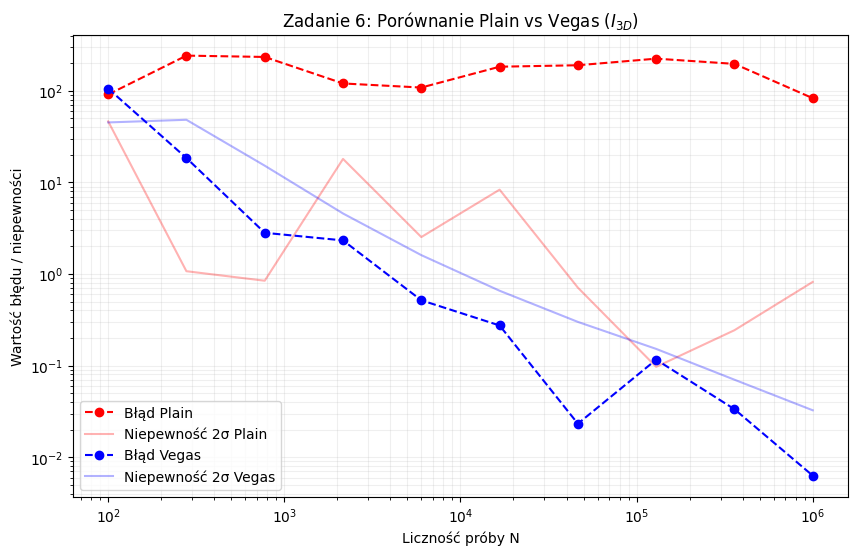

In [9]:
def f3d_vegas(x):
    # Postać dla biblioteki vegas
    return (1 + np.cos(x[0])) * (1 + np.cos(x[1])) * (1 + np.cos(x[2]))

# --- 2. Silnik symulacji ---
def run_comparison(dim=3):
    N_values = np.logspace(2, 6, 10).astype(int) # Od 100 do 1,000,000
    exact = I_3D_exact if dim == 3 else I_1D_exact
    vol = (2 * np.pi)**dim

    results = {
        'Plain': {'err': [], 'unc': []},
        'Vegas': {'err': [], 'unc': []}
    }

    for N in N_values:
        # --- PLAIN MC (Metoda podstawowa) ---
        # Losowanie punktów z rozkładu jednostronnego [cite: 296, 297]
        samples = np.random.uniform(-np.pi, np.pi, (N, dim))
        if dim == 3:
            f_vals = f3d(samples)
        else:
            f_vals = 1 + np.cos(samples[:, 0])

        I_hat_plain = vol * np.mean(f_vals) # Estymator całki [cite: 300]
        # Niepewność 2*sigma [cite: 134, 344]
        std_plain = vol * np.std(f_vals) / np.sqrt(N)
        results['Plain']['err'].append(abs(I_hat_plain - exact))
        results['Plain']['unc'].append(2 * std_plain)

        # --- VEGAS (Importance Sampling) ---
        # Metoda średniej ważonej [cite: 562, 607]
        region = [[-np.pi, np.pi]] * dim
        integ = vegas.Integrator(region)
        # Adaptacja (rozgrzewka) i właściwe całkowanie
        integ(f3d_vegas if dim == 3 else f1d, nitn=5, neval=N//10)
        res = integ(f3d_vegas if dim == 3 else f1d, nitn=10, neval=N//10)

        results['Vegas']['err'].append(abs(res.mean - exact))
        results['Vegas']['unc'].append(2 * res.sdev)

    return N_values, results

# --- 3. Generowanie wykresów porównawczych ---
def plot_results(N_values, results, title):
    plt.figure(figsize=(10, 6))
    colors = {'Plain': 'red', 'Vegas': 'blue'}

    for method, data in results.items():
        # Skala log-log zgodnie z instrukcją
        plt.loglog(N_values, data['err'], 'o--', color=colors[method], label=f'Błąd {method}')
        plt.loglog(N_values, data['unc'], '-', color=colors[method], alpha=0.3, label=f'Niepewność 2σ {method}')

    plt.title(title)
    plt.xlabel('Liczność próby N')
    plt.ylabel(r'Wartość błędu / niepewności')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# Uruchomienie dla obu przypadków
N_vals, res3d = run_comparison(dim=3)
plot_results(N_vals, res3d, r'Zadanie 6: Porównanie Plain vs Vegas ($I_{3D}$)')